In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # classifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Base Estimators
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Stacking Mechanism
from sklearn.ensemble import StackingClassifier

# Random State Initialization for Consistency
RANDOM_STATE = 0

Data preprocessing to prevent data leakage

In [2]:
from pathlib import Path
DATA_DIR = Path.cwd().parent / "data"

train_file_name = "UNSW_NB15_training-set.csv"  
test_file_name = "UNSW_NB15_testing-set.csv"    

train_path = DATA_DIR / train_file_name
test_path = DATA_DIR / test_file_name

print(f"Loading Training Data from: {train_path.resolve()}")
print(f"Loading Testing Data from:  {test_path.resolve()}")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Standardise Column Names to clean up whitespaces
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

# Clean up metadata/index columns to prevent data leakage
leakage_cols = ['id', 'Flow ID', 'Source IP', 'Src IP', 'Destination IP', 'Dst IP', 'Timestamp', 'External IP', 'attack_cat']
for df in [train_df, test_df]:
    df.drop(columns=[col for col in leakage_cols if col in df.columns], inplace=True, errors='ignore')

# Handle infinite and NaN values 
for df in [train_df, test_df]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

# Encode categorical columns if they exist to ensure data does not break (e.g., proto, service, state in UNSW-NB15)
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
if 'Label' in categorical_cols:
    categorical_cols.remove('Label')
if 'label' in categorical_cols:
    categorical_cols.remove('label')

if categorical_cols:
    print(f"Encoding categorical features: {categorical_cols}")
    for col in categorical_cols:
        # Map categories to their frequency in the training set
        freq_map = train_df[col].value_counts(normalize=True).to_dict()
        train_df[col] = train_df[col].map(freq_map).fillna(0)
        test_df[col] = test_df[col].map(freq_map).fillna(0)

# Map Target Label to Binary (0 = Benign, 1 = Attack)
# Standardize 'Label' vs 'label' casing
for df in [train_df, test_df]:
    if 'Label' in df.columns and 'label' not in df.columns:
        df.rename(columns={'Label': 'label'}, inplace=True)

# Convert string target labels (like 'BENIGN' / 'ATTACK') to binary 0 and 1
for df in [train_df, test_df]:
    if df['label'].dtype == 'object':
        df['label'] = df['label'].apply(lambda x: 0 if str(x).strip().upper() == 'BENIGN' else 1)

# Separate features and target
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

# Scaling features to transform numerical input to similar distribution
print("--- Scaling Features ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Loading Training Data from: C:\Users\mad\miniconda3\envs\xai_ids\data\UNSW_NB15_training-set.csv
Loading Testing Data from:  C:\Users\mad\miniconda3\envs\xai_ids\data\UNSW_NB15_testing-set.csv
Encoding categorical features: ['proto', 'service', 'state']
--- Scaling Features ---


Feature importance check


--- Running Baseline Feature Importance (Random Forest) ---


C:\Users\mad\AppData\Local\Temp\ipykernel_24112\2231470102.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X_train.columns[indices], palette="viridis")


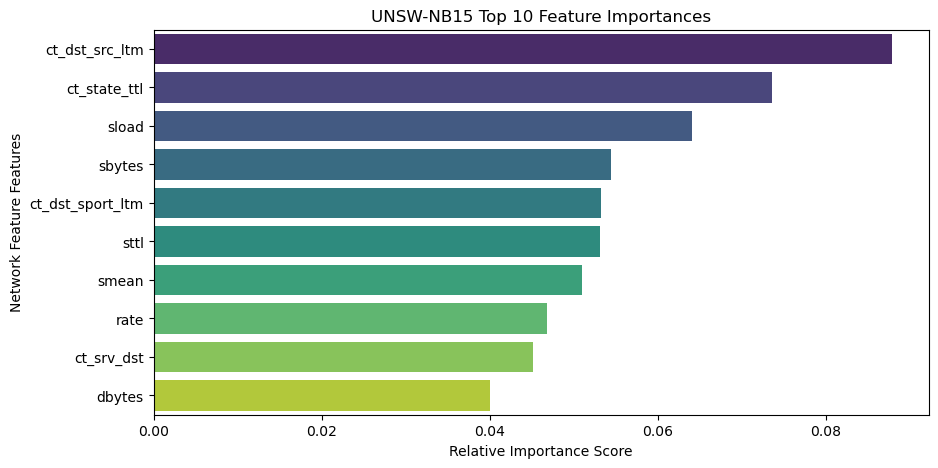

In [3]:
print("\n--- Running Baseline Feature Importance (Random Forest) ---")
fi_model = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)
fi_model.fit(X_train_scaled, y_train)

# Extrapolate top 10 features 
importances = fi_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=X_train.columns[indices], palette="viridis")
plt.title("UNSW-NB15 Top 10 Feature Importances")
plt.xlabel("Relative Importance Score")
plt.ylabel("Network Feature Features")
plt.show()

In [4]:
performance_metrics = {}
trained_models = {}

def evaluate_model(model, name, X_tr, y_tr, X_te, y_te):

    print(f"Training Framework: {name}...")

    model.fit(X_tr, y_tr)

    # Save trained model
    trained_models[name] = model

    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)

    performance_metrics[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }

    print(f"[{name}]")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}\n")

    return y_pred

In [5]:
# Evaluate Base Learners
y_pred_dt = evaluate_model(DecisionTreeClassifier(random_state=RANDOM_STATE), "Decision Tree", X_train_scaled, y_train, X_test_scaled, y_test)
y_pred_rf = evaluate_model(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), "Random Forest", X_train_scaled, y_train, X_test_scaled, y_test)
y_pred_xg = evaluate_model(xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'), "XGBoost Base", X_train_scaled, y_train, X_test_scaled, y_test)

Training Framework: Decision Tree...
[Decision Tree]
Accuracy : 0.8957
Precision: 0.9812
Recall   : 0.8632
F1 Score : 0.9184

Training Framework: Random Forest...
[Random Forest]
Accuracy : 0.9009
Precision: 0.9874
Recall   : 0.8655
F1 Score : 0.9224

Training Framework: XGBoost Base...
[XGBoost Base]
Accuracy : 0.9021
Precision: 0.9878
Recall   : 0.8669
F1 Score : 0.9234



How training works
- StackingClassifier: Split the training data into 5 folds 

For each fold: 
1. Train each base learner on 4 folds.
2. Predict the remaining fold (out-of-fold predictions).
3. Repeat until every training sample has an out-of-fold prediction from each base learner.
4. Combine these predictions into a new training dataset.
5. Train the XGBoost meta-learner on this new dataset.
6. Retrain all base learners on the full training dataset.

In [6]:
print("--- Initializing Validated Stacking Architecture ---")

# Define base structure
base_learners = [
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
    ('xg', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
]

# Meta-learner to optimize final predictions
meta_learner = xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_estimators=50)

# Build unified StackingClassifier with 5-Fold cross validation
stacking_pipeline = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5, 
    n_jobs=-1,
    passthrough=False
)

# Run engine
y_pred_stk = evaluate_model(stacking_pipeline, "Stacking Model (Hybrid Engine)", X_train_scaled, y_train, X_test_scaled, y_test)

--- Initializing Validated Stacking Architecture ---
Training Framework: Stacking Model (Hybrid Engine)...
[Stacking Model (Hybrid Engine)]
Accuracy : 0.8964
Precision: 0.9891
Recall   : 0.8572
F1 Score : 0.9184



=== FINAL PERFORMANCE METRICS COMPARISON ===


,Accuracy,Precision,Recall,F1-Score
Decision Tree,0.8957,0.9812,0.8632,0.9184
Random Forest,0.9009,0.9874,0.8655,0.9224
XGBoost Base,0.9021,0.9878,0.8669,0.9234
Stacking Model (Hybrid Engine),0.8964,0.9891,0.8572,0.9184


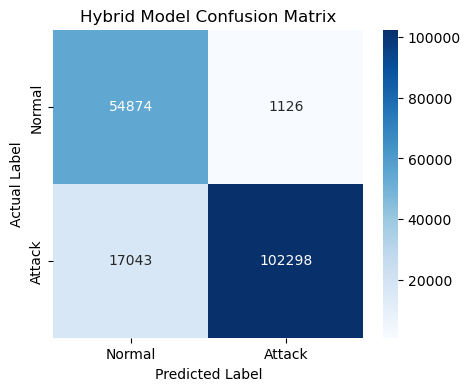

In [7]:
# Convert tracking storage metrics into a presentable Dataframe
results_df = pd.DataFrame(performance_metrics).T

print("=== FINAL PERFORMANCE METRICS COMPARISON ===")
display(results_df.round(4))

# Generate Confusion Matrix for the hybrid architecture
cm = confusion_matrix(y_test, y_pred_stk)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Hybrid Model Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

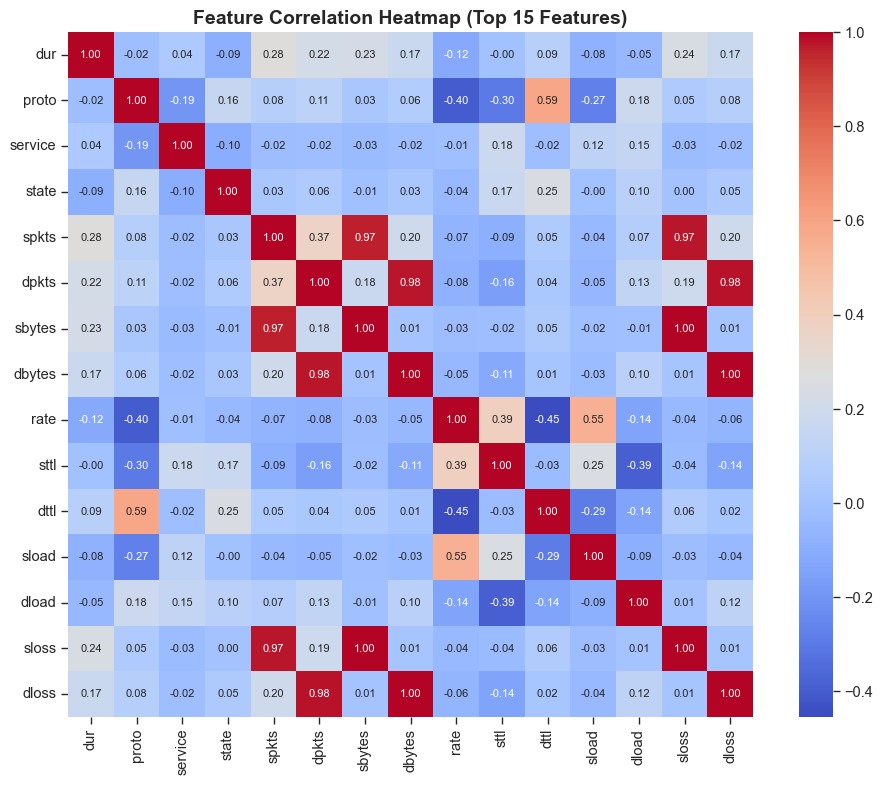

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set clean visualization parameters for papers
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
fig_color = "#2b5c8f"


# Feature Correlation Heatmap ---
# Showing correlation of top features to keep the visual readable
plt.figure(figsize=(10, 8))
# Identify numeric columns from your scaled feature matrix
numeric_cols = train_df.select_dtypes(include=[np.number]).columns[:15] # Top 15 features for clean viewing
corr_matrix = train_df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True,
            annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap (Top 15 Features)", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt

print("Generating SHAP Analysis...")

# 1. Fetch model wrapper
best_model = trained_models["Stacking Model (Hybrid Engine)"]

# 2. Rename dataset columns
X_test_sampled = X_test.sample(
    n=min(500, len(X_test)),
    random_state=42
)

# 3. Using .predict_proba tells SHAP to treat it as a function callback,
# avoiding the C++ TreeExplainer parameter parser bug entirely.
explainer = shap.Explainer(best_model.predict_proba, X_test_sampled)

# 4. Compute SHAP values
shap_values = explainer(X_test_sampled)

# 5. Extract the probabilities for the positive class (Class 1) to keep plot dimensions correct for binary/multi-class outcomes
if len(shap_values.shape) == 3:
    shap_values_plot = shap_values[:, :, 1]
else:
    shap_values_plot = shap_values

# 6. Generate Bar Plot
plt.figure(figsize=(12, 6))
shap.plots.bar(shap_values_plot, show=False)
plt.title("SHAP Global Feature Importance (Bar)")
plt.tight_layout()
plt.show()

# 7. Generate Beeswarm Plot
plt.figure(figsize=(12, 8))
shap.plots.beeswarm(
    shap_values_plot,
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm Plot")
plt.tight_layout()
plt.show()

Generating SHAP Analysis...


c:\Users\mad\miniconda3\envs\xai_ids\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\mad\miniconda3\envs\xai_ids\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\mad\miniconda3\envs\xai_ids\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\mad\miniconda3\envs\xai_ids\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\mad\miniconda3\envs\xai_ids\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [ ]:
import pickle

# Export trained Random Forest Model
model_filename = "ids_rf_model.pkl"
with open(model_filename, "wb") as file:
    pickle.dump(results_df, file)  
print(f"Model successfully saved to {model_filename}")

# Export feature names array (Crucial for API column alignment!)p
features_filename = "model_features.pkl"
with open(features_filename, "wb") as file:
    # Double check that 'feature_names_all' is the exact name of your feature list!
    pickle.dump(results_df, file)  
print(f"Feature schema successfully saved to {features_filename}")

Model successfully saved to ids_rf_model.pkl
Feature schema successfully saved to model_features.pkl
